# Week 1: Auditing algorithmic fairness with ACSIncome dataset

**Learning goals**

1. Separate a target label, a prediction, and a decision.
2. Validate performance and group fairness.
3. Connect independence, separation, sufficiency, and calibration to their assumptions.

**Project 1 (Week 1)**

1. Guided - Auditing algorithmic fairness with ACSIncome dataset
2. Transfer your learning and perform an audit on the Portuguese banking marketing campaign dataset


### Task 1: The task predicts whether annual income exceeds USD 50,000 using 2018 ACS data. `SEX` is the binary coding available in this survey extract. It is not a complete measurement of gender identity.

In [1]:
# pip -q install folktables fairlearn cleanlab scikit-learn pandas matplotlib seaborn

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import fairlearn

from IPython.display import display
from folktables import ACSDataSource, ACSIncome
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_predict
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, roc_auc_score, log_loss,
    brier_score_loss, confusion_matrix, precision_score, recall_score,
)
from fairlearn.metrics import (
    MetricFrame, selection_rate, count, true_positive_rate,
    false_positive_rate, demographic_parity_difference,
    demographic_parity_ratio, equalized_odds_difference,
    equalized_odds_ratio,
)

RANDOM_STATE = 42
STATE = "CA"
MAX_SAMPLES = 50_000

## 1. Load and document the data

Before modelling, answer:

- What population is represented?
American population + Puerto Rico
- What is the prediction target and who constructed it?
Prediction target is total annual income. It was constructed by Frances Ding, Moritz Hardt, John Miller, and Ludwig Schmidt
- Which variables are measurements, proxies, or administratively defined categories? \
Age: M
COW: A
SCHL: M
MAR: M
OCCP: A
POBP: M
RELP: A
Hours worked: P
SEX: M
RAC1P: A

Age, SEX, race, school, marital status, employment can all be proxies as they are correlated with income

- Have a look at dataset description for code names ('columns') and their description - https://fairlearn.org/main/user_guide/datasets/acs_income.html

In [3]:
source = ACSDataSource(survey_year="2018", horizon="1-Year", survey="person")
acs = source.get_data(states=[STATE], download=True)
X_all, y_all, race_codes = ACSIncome.df_to_pandas(acs)

X_all = X_all.reset_index(drop=True)
y_reference = y_all.squeeze().astype(int).reset_index(drop=True)
race_codes = race_codes.squeeze().reset_index(drop=True)
sex_group = X_all["SEX"].map({1: "Male", 2: "Female"}).fillna("Unknown")
race_names = {
    1: "White", 2: "Black", 3: "American Indian", 4: "Alaska Native",
    5: "AIAN specified/other", 6: "Asian", 7: "Pacific Islander",
    8: "Other race", 9: "Two or more races",
}
race_group = race_codes.map(race_names).fillna("Unknown")

strata = y_reference.astype(str) + "_" + sex_group.astype(str)
if len(X_all) > MAX_SAMPLES:
    keep, _ = train_test_split(
        np.arange(len(X_all)), train_size=MAX_SAMPLES,
        random_state=RANDOM_STATE, stratify=strata,
    )
    X_all = X_all.iloc[keep].reset_index(drop=True)
    y_reference = y_reference.iloc[keep].reset_index(drop=True)
    sex_group = sex_group.iloc[keep].reset_index(drop=True)
    race_group = race_group.iloc[keep].reset_index(drop=True)

display(X_all.head())
display(pd.crosstab(sex_group, y_reference, normalize="index").rename(columns={0:"income<=50k",1:"income>50k"}))
print("Rows:", len(X_all), "Features:", X_all.shape[1])

,AGEP,COW,SCHL,MAR,OCCP,POBP,RELP,WKHP,SEX,RAC1P
0,47.0,1.0,22.0,1.0,5740.0,6.0,1.0,40.0,2.0,1.0
1,44.0,1.0,19.0,1.0,440.0,6.0,0.0,45.0,1.0,1.0
2,41.0,4.0,16.0,1.0,4220.0,12.0,0.0,42.0,1.0,1.0
3,58.0,1.0,18.0,5.0,3605.0,6.0,0.0,40.0,1.0,2.0
4,36.0,1.0,19.0,1.0,1006.0,361.0,5.0,40.0,1.0,1.0


PINCP,income<=50k,income>50k
SEX,,
Female,0.650932,0.349068
Male,0.534432,0.465568


Rows: 50000 Features: 10


### Label notation used throughout the course

| Symbol | Meaning | Use |
|---|---|---|
| $Y^{ref}$ | Best available reference outcome | Final validation and test audit |
| $Y^{obs}$ | Label available to us; in real-life | Training and realistic validation |
| $S=P(\hat Y=1)$ | Model score | Ranking and calibration |
| $\hat Y$ | Thresholded or postprocessed decision | Decision metrics |

In Week 1, $Y^{obs}=Y^{ref}$. Later weeks deliberately separate them. “Reference” is more accurate than “ground truth”: real labels can still be incomplete or contestable.

In [4]:
idx = np.arange(len(X_all))
strata = y_reference.astype(str) + "_" + sex_group.astype(str)
train_idx, temp_idx = train_test_split(idx, test_size=.40, random_state=RANDOM_STATE, stratify=strata)
val_idx, test_idx = train_test_split(
    temp_idx, test_size=.50, random_state=RANDOM_STATE,
    stratify=strata.iloc[temp_idx],
)

def take(x, ids):
    return x.iloc[ids].reset_index(drop=True)

X_train, X_val, X_test = [take(X_all, z) for z in (train_idx, val_idx, test_idx)]
y_train, y_val, y_test = [take(y_reference, z) for z in (train_idx, val_idx, test_idx)]
A_train, A_val, A_test = [take(sex_group, z) for z in (train_idx, val_idx, test_idx)]
R_train, R_val, R_test = [take(race_group, z) for z in (train_idx, val_idx, test_idx)]

display(pd.DataFrame({
    "split": ["train", "validation", "test"],
    "n": [len(X_train), len(X_val), len(X_test)],
    "positive_rate": [y_train.mean(), y_val.mean(), y_test.mean()],
    "female_fraction": [(A_train=="Female").mean(), (A_val=="Female").mean(), (A_test=="Female").mean()],
}))

,split,n,positive_rate,female_fraction
0,train,30000,0.4106,0.472
1,validation,10000,0.4105,0.472
2,test,10000,0.4106,0.472


## 2. Fit a transparent baseline

We retain `SEX` and `RAC1P` for the first model. (Later, compare a model that excludes them.)

**Removing a sensitive attribute does not remove proxies and is not itself a fairness guarantee** - We discuss this in lecture

In [5]:
NUMERIC = ["AGEP", "WKHP"]

def make_model(frame, C=1.0):
    numeric = [c for c in NUMERIC if c in frame.columns]
    categorical = [c for c in frame.columns if c not in numeric]
    prep = ColumnTransformer([
        ("num", StandardScaler(), numeric),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical),
    ])
    return Pipeline([
        ("preprocess", prep),
        ("model", LogisticRegression(max_iter=1000, C=C)),
    ])

FEATURES = list(X_train.columns)
model = make_model(X_train[FEATURES])
model.fit(X_train[FEATURES], y_train)
val_score = model.predict_proba(X_val[FEATURES])[:, 1]
val_pred = (val_score >= .50).astype(int)

## 3. Metric families

| Family | Examples | Question | Important limitation |
|---|---|---|---|
| Performance | Accuracy, balanced accuracy, AUROC, log loss | Does the model work overall? | Can conceal subgroup failures |
| Independence | Selection rate, demographic parity difference/ratio | Are decisions distributed similarly? | Ignores the reference outcome |
| Separation | TPR/FPR, equal opportunity, equalized odds | Are errors similar conditional on $Y$? | Depends directly on label validity |
| Sufficiency | PPV/NPV | Does a decision mean the same thing across groups? | Threshold-dependent and unstable in small groups |

There is no universally correct fairness metric. The choice depends on the decision, harms, label-generating process, and deployment context.

Read the documentation of fairlearn.metrics and sklearn.metrics to identify the performance measures needed to assess Independence, Separation (Equalized Odds), Equal Opportunity, and Sufficiency. Add them to the analysis of the classifier as illustrated above, and create fairness diagnostics metrics that consider a ratio of metrics for the groups at hand, in a way that is consistent with each of the fairness criteria.

If you apply the standard practice of "more than 20% discrepancy is a problem" -- which combinations of datasets and fairness criteria lead to a conclusion of problematic bias?

In [6]:
# TODO # instead of using fairlearn/sklearn metrics, code your own using numpy

def false_positive_rate_metric(y_true, y_pred):
    # raise NotImplementedError("TODO: implement false_positive_rate_metric")
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0,1]).ravel()
    return fp/(tn+fp) if (tn+fp)>0 else np.nan

def true_negative_rate_metric(y_true, y_pred):
    # raise NotImplementedError("TODO: implement true_negative_rate_metric")
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0,1]).ravel()
    return tn/(tn+fp) if (tn+fp)>0 else np.nan

def negative_predictive_value_metric(y_true, y_pred):
    # raise NotImplementedError("TODO: implement negative_predictive_value_metric")
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0,1]).ravel()
    return tn/(tn+fn) if (tn+fn)>0 else np.nan

metrics = {
    "n": count,
    "accuracy": accuracy_score,
    "balanced_accuracy": balanced_accuracy_score,
    "selection_rate": selection_rate,
    "TPR_recall": recall_score,
    "FPR": false_positive_rate_metric,
    "PPV_precision": lambda y, p: precision_score(y, p, zero_division=0),
    "NPV": negative_predictive_value_metric,
    "TNR": true_negative_rate_metric,
}

mf = MetricFrame(metrics=metrics, y_true=y_val, y_pred=val_pred, sensitive_features=A_val)

print("Overall threshold metrics")
display(pd.Series(mf.overall))
print("By group")
display(mf.by_group)
print("Maximum minus minimum")
display(pd.Series(mf.difference(method="between_groups")))
print("Minimum divided by maximum")
display(pd.Series(mf.ratio(method="between_groups")))

# raise NotImplementedError("TODO: calculate the fairness summary metrics")
fairness_summary = pd.Series({
    "demographic_parity_difference": demographic_parity_difference(y_val, val_pred, sensitive_features=A_val), 
    "demographic_parity_ratio": demographic_parity_ratio(y_val, val_pred, sensitive_features=A_val),
    "equalized_odds_difference": equalized_odds_difference(y_val, val_pred, sensitive_features=A_val),
    "equalized_odds_ratio": equalized_odds_ratio(y_val, val_pred, sensitive_features=A_val),
})
display(fairness_summary)

Overall threshold metrics


n                    10000.000000
accuracy                 0.818400
balanced_accuracy        0.812389
selection_rate           0.410500
TPR_recall               0.778806
FPR                      0.154029
PPV_precision            0.778806
NPV                      0.845971
TNR                      0.845971
dtype: float64

By group


,n,accuracy,balanced_accuracy,selection_rate,TPR_recall,FPR,PPV_precision,NPV,TNR
SEX,,,,,,,,,
Female,4720.0,0.817797,0.796255,0.339195,0.724954,0.132444,0.745784,0.854761,0.867556
Male,5280.0,0.818939,0.818678,0.474242,0.814890,0.177534,0.799920,0.836095,0.822466


Maximum minus minimum


n                    560.000000
accuracy               0.001143
balanced_accuracy      0.022423
selection_rate         0.135048
TPR_recall             0.089936
FPR                    0.045090
PPV_precision          0.054136
NPV                    0.018666
TNR                    0.045090
dtype: float64

Minimum divided by maximum


n                    0.893939
accuracy             0.998605
balanced_accuracy    0.972611
selection_rate       0.715235
TPR_recall           0.889635
FPR                  0.746021
PPV_precision        0.932323
NPV                  0.978162
TNR                  0.948027
dtype: float64

demographic_parity_difference    0.135048
demographic_parity_ratio         0.715235
equalized_odds_difference        0.089936
equalized_odds_ratio             0.746021
dtype: float64

In [7]:
# raise NotImplementedError("TODO: calculate the overall probability metrics")
overall_probability_metrics = pd.Series({
    "ROC_AUC": roc_auc_score(y_val, val_score),
    "log_loss": log_loss(y_val, val_score)
})
display(overall_probability_metrics)

prob_rows = []
for g in A_val.unique():
    m = A_val.eq(g).to_numpy()
    prob_rows.append({
        "group": g, "n": m.sum(),
        "ROC_AUC": roc_auc_score(y_val[m], val_score[m]),
        "log_loss": log_loss(y_val[m], val_score[m])
    })
display(pd.DataFrame(prob_rows).set_index("group"))

ROC_AUC     0.896257
log_loss    0.401263
dtype: float64

,n,ROC_AUC,log_loss
group,,,
Female,4720,0.893558,0.391373
Male,5280,0.894881,0.410104


### Interpretation checkpoint

Think:

1. Which group has the higher selection rate, and by how much?\
Men - the model predicts that men earn more than 50k in 47% of times, while only at 33% times for women
2. Which group has the higher FPR and which has the higher TPR?\
Men has higher FPR and TPR, which means the model makes more positive predictions for men
3. Does the direction of the PPV gap match the direction of the selection-rate gap?\ 
Yes. The precision is worse for women, because they less often is categorized as having more than 50k (PPV gap)
4. What can you **not** conclude from these numbers alone?\ 
How many women or men is above 50k? Why we might see this difference in model prediction  

**Optional: Write down your interpretation**
1. Selection rate comparison: ...
2. FPR/TPR comparison: ...
3. PPV gap vs. selection-rate gap: ...
4. What you cannot conclude: ...

## 4. Thresholds change decisions, not score quality

Inspect a threshold sweep. A fairness conclusion based on one arbitrary threshold is incomplete.

,threshold,accuracy,selection_gap,TPR_gap,FPR_gap
0,0.10,0.6803,0.109511,0.008602,0.090762
1,0.15,0.7248,0.113431,0.010343,0.082318
2,0.20,0.7579,0.116763,0.020991,0.070918
3,0.25,0.7800,0.123565,0.030407,0.070098
4,0.30,0.7942,0.130239,0.045087,0.068281
5,0.35,0.8051,0.131638,0.053676,0.062790
6,0.40,0.8122,0.133796,0.063461,0.059303
7,0.45,0.8173,0.134454,0.072664,0.054029
8,0.50,0.8184,0.135048,0.089936,0.045090
9,0.55,0.8172,0.134961,0.100911,0.040106


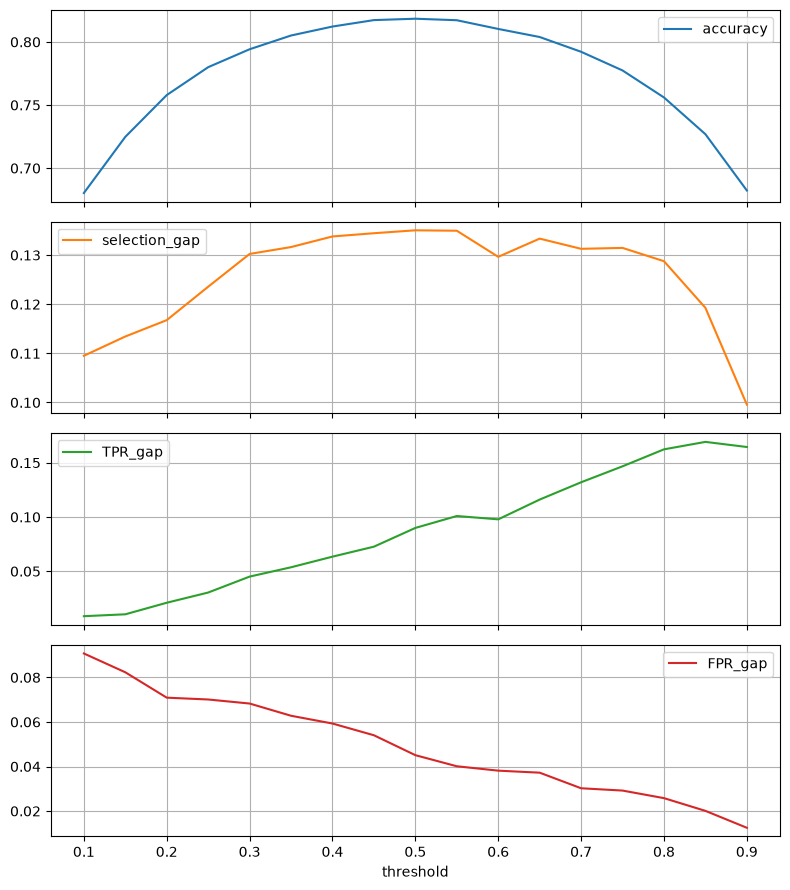

In [8]:
rows = []
for threshold in np.linspace(.1, .9, 17):
    pred = (val_score >= threshold).astype(int)
    frame = MetricFrame(
        metrics={"selection": selection_rate, "TPR": recall_score, "FPR": false_positive_rate_metric},
        y_true=y_val, y_pred=pred, sensitive_features=A_val,
    )
    rows.append({
        "threshold": threshold,
        "accuracy": accuracy_score(y_val, pred),
        "selection_gap": frame.difference()["selection"],
        "TPR_gap": frame.difference()["TPR"],
        "FPR_gap": frame.difference()["FPR"],
    })
sweep = pd.DataFrame(rows)
display(sweep)
sweep.set_index("threshold").plot(subplots=True, figsize=(8,9), grid=True)
plt.tight_layout()

## 5. Sensitive-feature removal and intersectional audit

Complete both tasks. Report group-specific values and subgroup counts, not only gaps.

Removing sensitive-feature solve the problem? What are other short-comings you can think of?

In [10]:
# TODO 1: fit a second model after removing SEX and RAC1P from predictive features.
# Retain A_val and R_val for auditing.
FEATURES_WITHOUT_A = [c for c in FEATURES if c not in ["SEX", "RAC1P"]]

model_without_a =  make_model(X_train[FEATURES_WITHOUT_A])
model_without_a.fit(X_train[FEATURES_WITHOUT_A], y_train)
score_without_a = model_without_a.predict_proba(X_val[FEATURES])[:,1]
pred_without_a = (score_without_a >= .50).astype(int)

In [ ]:
mf_without_a = MetricFrame(metrics=metrics, y_true=y_val, y_pred=pred_without_a, sensitive_features=A_val)

print("Overall threshold metrics")
print("By group")
display(mf_without_a.by_group)

Overall threshold metrics


n                    10000.000000
accuracy                 0.819500
balanced_accuracy        0.813544
selection_rate           0.410600
TPR_recall               0.780268
FPR                      0.153181
PPV_precision            0.780078
NPV                      0.846963
TNR                      0.846819
dtype: float64

By group


,n,accuracy,balanced_accuracy,selection_rate,TPR_recall,FPR,PPV_precision,NPV,TNR
SEX,,,,,,,,,
Female,4720.0,0.819068,0.806529,0.365890,0.765027,0.151969,0.729589,0.870698,0.848031
Male,5280.0,0.819886,0.817990,0.450568,0.790480,0.154500,0.816730,0.822475,0.845500


In [ ]:
# Optional

# TODO 2: create an intersectional sensitive feature such as SEX x RACE.
# Require a minimum group size before interpreting a result.
intersection = A_val.astype(str) + " | " + R_val.astype(str)
display(intersection.value_counts().head(15))

## Task 2: Perform fairness auditing on a marketing campaign dataset

Repeat the analysis on a new dataset - https://fairlearn.org/v0.13/api_reference/generated/fairlearn.datasets.fetch_bank_marketing.html

What do you learn about bias diagnostic? How are these metrics different?

- What population is represented?\
Portugese population
- What is the prediction target and who constructed it?\
Prediction target is whether or not a client has subscribed a term deposit. It was constructed by Moro, Rita & Cortez
- Which variables are measurements, proxies, or administratively defined categories?\
Measurements: age, default, balance, housing, loan, contact, day_of_week, month, duration, campaign, pdays, previous\
Administratively defined: job, marital, education, poutcome\
Proxies: job (?), marital (?), education (?), default, balance, housing, loan, campaign (?)

In [13]:
from fairlearn.datasets import fetch_bank_marketing

bank_data = fetch_bank_marketing()
print(bank_data.data.shape)
print(bank_data.target.shape)
print(bank_data.feature_names)

(45211, 16)
(45211,)
['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16']


In [16]:
X = bank_data.data
y = bank_data.target

X = X.reset_index(drop=True)
y_ref = y.squeeze().astype(int).reset_index(drop=True)

In [20]:
job_group = X["V2"]

display(X.head())
display(pd.crosstab(job_group, y_ref, normalize="index").rename(columns={2:"no",1:"yes"}))
print("Rows:", len(X), "Features:", X.shape[1])

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown


Class,yes,no
V2,,
admin.,0.877973,0.122027
blue-collar,0.927250,0.072750
entrepreneur,0.917283,0.082717
housemaid,0.912097,0.087903
management,0.862444,0.137556
retired,0.772085,0.227915
self-employed,0.881571,0.118429
services,0.911170,0.088830
student,0.713220,0.286780


Rows: 45211 Features: 16


In [22]:
idx = np.arange(len(X))
strata_job = y_ref.astype(str) + "_" + job_group.astype(str)
train_idx, temp_idx = train_test_split(idx, test_size=.40, random_state=RANDOM_STATE, stratify=strata_job)
val_idx, test_idx = train_test_split(
    temp_idx, test_size=.50, random_state=RANDOM_STATE,
    stratify=strata.iloc[temp_idx],
)

def take(x, ids):
    return x.iloc[ids].reset_index(drop=True)

Xj_train, Xj_val, Xj_test = [take(X, z) for z in (train_idx, val_idx, test_idx)]
yj_train, yj_val, yj_test = [take(y_ref, z) for z in (train_idx, val_idx, test_idx)]
J_train, J_val, J_test = [take(job_group, z) for z in (train_idx, val_idx, test_idx)]

display(pd.DataFrame({
    "split": ["train", "validation", "test"],
    "n": [len(Xj_train), len(Xj_val), len(Xj_test)],
    "positive_rate": [(yj_train-1).mean(), (yj_val-1).mean(), (yj_test-1).mean()]
}))

,split,n,positive_rate
0,train,27126,0.117010
1,validation,9042,0.116899
2,test,9043,0.116997


## 📝 Project 1 Submission Guidelines

**Format:** Project 1 will be submitted as an **A0 Poster**. 

**Week 1 Contribution:**
The findings and discussions generated from this Week 1 notebook should form the foundation of your project and cover approximately **1/3 of your final poster**. 

When preparing your poster, ensure that this section includes:
* Clearly outline the context, goals, and intended real-world impact of the model. 
* Explain what the different fairness metrics represent in the context of this specific use case (e.g., what does a disparity in False Positive Rate mean for the individuals actually affected?).
* Provide a short analysis of the bias present in the ACSIncome dataset and Bank Marketing dataset - from your exploratory data analysis and the fairness metric evaluations conducted in this notebook.